In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from urllib.request import urlopen
import plotly.express as px
import plotly.graph_objects as go
from plotly.offline import init_notebook_mode , iplot
init_notebook_mode(connected=True)

In [75]:
medical = pd.read_csv('/content/Medicare_Hospital_Spending_by_Claim.csv')

In [3]:
medical.head()

,index,Hospital Name,Provider Number,State,Period,Claim Type,Avg Spending Per Episode (Hospital),Avg Spending Per Episode (State),Avg Spending Per Episode (Nation),Percent of Spending (Hospital),Percent of Spending (State),Percent of Spending (Nation),Measure Start Date,Measure End Date
0,0,HELEN KELLER HOSPITAL,10019,AL,During Index Hospital Admission,Skilled Nursing Facility,$0,$0,$0,0%,0%,0%,01/01/1012015,01/01/12312015
1,1,HELEN KELLER HOSPITAL,10019,AL,During Index Hospital Admission,Durable Medical Equipment,$18,$31,$24,0.1%,0.16%,0.12%,01/01/1012015,01/01/12312015
2,2,HELEN KELLER HOSPITAL,10019,AL,During Index Hospital Admission,Carrier,$1062,$1480,$1540,6.01%,7.71%,7.52%,01/01/1012015,01/01/12312015
3,3,HELEN KELLER HOSPITAL,10019,AL,1 through 30 days After Discharge from Index H...,Home Health Agency,$917,$948,$816,5.19%,4.94%,3.98%,01/01/1012015,01/01/12312015
4,4,HELEN KELLER HOSPITAL,10019,AL,1 through 30 days After Discharge from Index H...,Hospice,$172,$154,$122,0.97%,0.8%,0.6%,01/01/1012015,01/01/12312015


In [4]:
medical['Avg Spending Per Episode (Hospital)'] = medical['Avg Spending Per Episode (Hospital)'].str.replace('$', '', )
medical['Avg Spending Per Episode (State)'] = medical['Avg Spending Per Episode (State)'].str.replace('$', '')
medical['Avg Spending Per Episode (Nation)'] = medical['Avg Spending Per Episode (Nation)'].str.replace('%', '')
medical['Avg Spending Per Episode (Nation)'] = medical['Avg Spending Per Episode (Nation)'].str.replace('$', '')

In [5]:
medical['Percent of Spending (Hospital)'] = medical['Percent of Spending (Hospital)'].str.replace('%', '')
medical['Percent of Spending (State)'] = medical['Percent of Spending (State)'].str.replace('%', '')
medical['Percent of Spending (Nation)'] = medical['Percent of Spending (Nation)'].str.replace('%', '')

In [6]:
medical['Measure Start Date'] = pd.get_dummies('Measure Start Date')
medical['Measure End Date'] = pd.get_dummies('Measure End Date')

In [86]:
South_alabama = medical[(medical['Hospital Name'] == 'SOUTH ALABAMA MEDICAL CENTER') & (medical['Claim Type'] == 'READMISSIONS')]

In [87]:
medical.head()

,index,Hospital Name,Provider Number,State,Period,Claim Type,Avg Spending Per Episode (Hospital),Avg Spending Per Episode (State),Avg Spending Per Episode (Nation),Percent of Spending (Hospital),Percent of Spending (State),Percent of Spending (Nation),Measure Start Date,Measure End Date
0,0,HELEN KELLER HOSPITAL,10019,AL,During Index Hospital Admission,Skilled Nursing Facility,0,0,0,0,0,0,True,True
1,1,HELEN KELLER HOSPITAL,10019,AL,During Index Hospital Admission,Durable Medical Equipment,18,31,24,0.1,0.16,0.12,NaN,NaN
2,2,HELEN KELLER HOSPITAL,10019,AL,During Index Hospital Admission,Carrier,1062,1480,1540,6.01,7.71,7.52,NaN,NaN
3,3,HELEN KELLER HOSPITAL,10019,AL,1 through 30 days After Discharge from Index H...,Home Health Agency,917,948,816,5.19,4.94,3.98,NaN,NaN
4,4,HELEN KELLER HOSPITAL,10019,AL,1 through 30 days After Discharge from Index H...,Hospice,172,154,122,0.97,0.8,0.6,NaN,NaN


In [20]:
medical.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69784 entries, 0 to 69783
Data columns (total 14 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   index                                69784 non-null  int64 
 1   Hospital Name                        69784 non-null  object
 2   Provider Number                      69784 non-null  int64 
 3   State                                69784 non-null  object
 4   Period                               69784 non-null  object
 5   Claim Type                           69784 non-null  object
 6   Avg Spending Per Episode (Hospital)  69784 non-null  object
 7   Avg Spending Per Episode (State)     69784 non-null  object
 8   Avg Spending Per Episode (Nation)    69784 non-null  object
 9   Percent of Spending (Hospital)       69784 non-null  object
 10  Percent of Spending (State)          69784 non-null  object
 11  Percent of Spending (Nation)         6978

In [88]:
medical.describe()

,index,Provider Number
count,69784.00000,69784.000000
mean,34891.50000,262588.332282
std,20145.04993,161016.595297
min,0.00000,10001.000000
25%,17445.75000,110094.250000
50%,34891.50000,260022.500000
75%,52337.25000,390146.250000
max,69783.00000,670108.000000


In [7]:
medical['Period'].value_counts()

,count
Period,
During Index Hospital Admission,22204
1 through 30 days After Discharge from Index Hospital Admission,22204
1 to 3 days Prior to Index Hospital Admission,22204
Complete Episode,3172


<Axes: xlabel='count', ylabel='Period'>

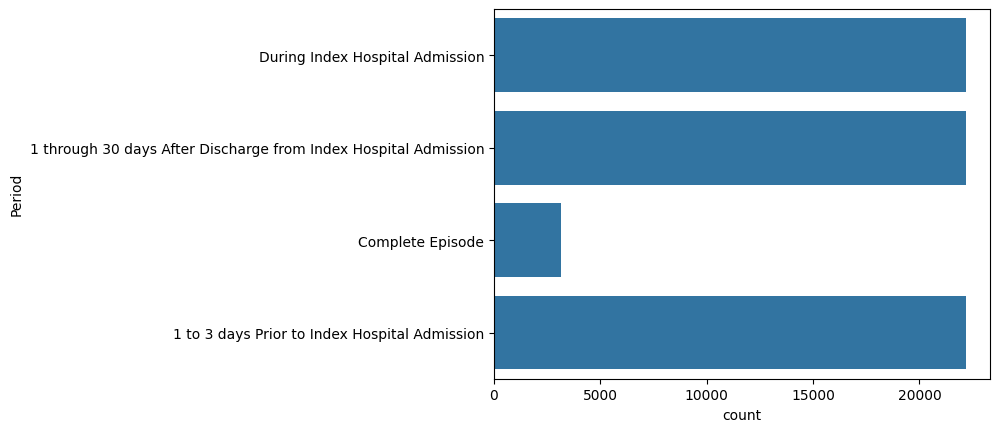

In [8]:
sns.countplot(medical['Period'])

In [90]:
def chaning_period_name(previous_name):
  if previous_name == '1 through 30 days after discharge from index hospital admination':
    return 'After Discharge'
  elif previous_name == 'During index adminssion':
    return 'During Admission'
  elif previous_name =='1 to 30 day priro to index hospital admission':
    return 'Priro Hospital Admission'
  elif previous_name == 'Complete Episode':

    return 'Overall'
medical['Period'] = medical['Period'].map(chaning_period_name)


<Axes: xlabel='count', ylabel='Claim Type'>

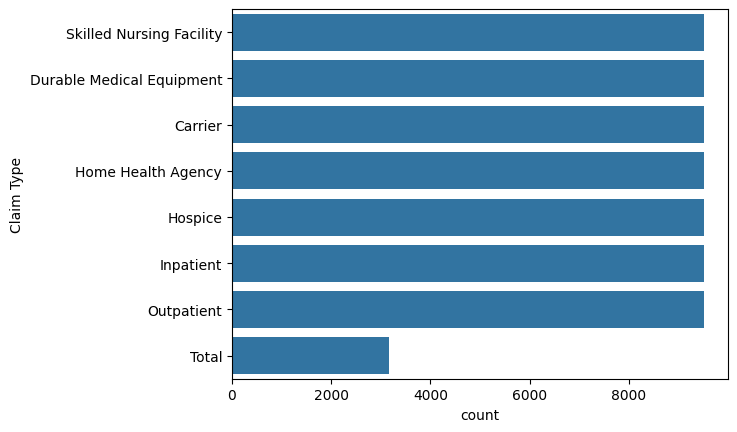

In [11]:
sns.countplot(medical['Claim Type'])

In [91]:
medical['Period']

,Period
0,None
1,None
2,None
3,None
4,None
...,...
69779,None
69780,None
69781,None
69782,None


In [92]:
total = medical[(medical['Claim Type'] == 'Total')]

In [93]:
total['State'].unique()

array(['AL', 'CA', 'AK', 'AZ', 'AR', 'CO', 'FL', 'GA', 'CT', 'DC', 'IL',
       'ID', 'IN', 'HI', 'DE', 'LA', 'ME', 'MA', 'KY', 'KS', 'IA', 'MS',
       'MO', 'MN', 'MI', 'NY', 'NM', 'NJ', 'OH', 'NE', 'MT', 'ND', 'NC',
       'NV', 'NH', 'PA', 'SC', 'WY', 'TX', 'TN', 'SD', 'RI', 'OK', 'OR',
       'UT', 'VA', 'WA', 'VT', 'WI', 'WV'], dtype=object)

In [12]:
avg_per_hospital = []
total_avg_hospital = medical.agg({'Avg Spending Per Episode (Hospital)':sum})[0]
all_states = medical['State'].nunique()


for i in all_states:
  state_value = medical.agg({'Avg Spending Per Episode (Hospital)':sum})[0]
  avg_per_hospital.append(state_value)


/tmp/ipython-input-12-1682309709.py:2: FutureWarning:

The provided callable <built-in function sum> is currently using Series.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.

/tmp/ipython-input-12-1682309709.py:2: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



TypeError: 'int' object is not iterable

In [95]:
top_ten = medical['Avg Spending Per Episode (State)'].head(n=10)
top_ten
plt.figure(figsize=(10,5))
plt.pie()


,Avg Spending Per Episode (State)
0,0
1,31
2,1480
3,948
4,154
5,2634
6,596
7,2626
8,126
9,1046


In [106]:
top_ten_states= medical.groupby('State')['Percent of Spending (Nation)'].count().head(10)
top_ten_states

,Percent of Spending (Nation)
State,
AK,176
AL,1804
AR,946
AZ,1364
CA,6380
CO,1012
CT,638
DC,154
DE,132


In [117]:
medical.columns

Index(['index', 'Hospital Name', 'Provider Number ', 'State', 'Period',
       'Claim Type', 'Avg Spending Per Episode (Hospital)',
       'Avg Spending Per Episode (State)', 'Avg Spending Per Episode (Nation)',
       'Percent of Spending (Hospital)', 'Percent of Spending (State)',
       'Percent of Spending (Nation)', 'Measure Start Date',
       'Measure End Date'],
      dtype='object')

(array([], dtype=float64), [])

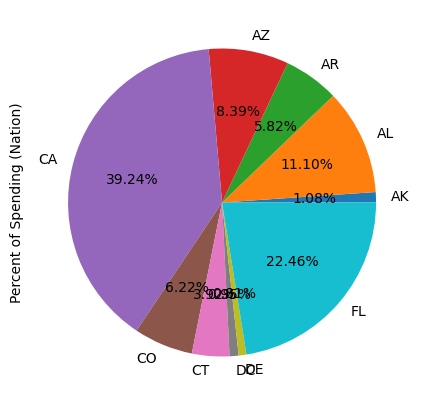

In [116]:
plt.figure(figsize=(10,5))
top_ten_states.plot(kind='pie', figsize=(10,5), autopct='%1.2f%%')
plt.xticks(encoding=45)

<Axes: xlabel='Hospital Name'>

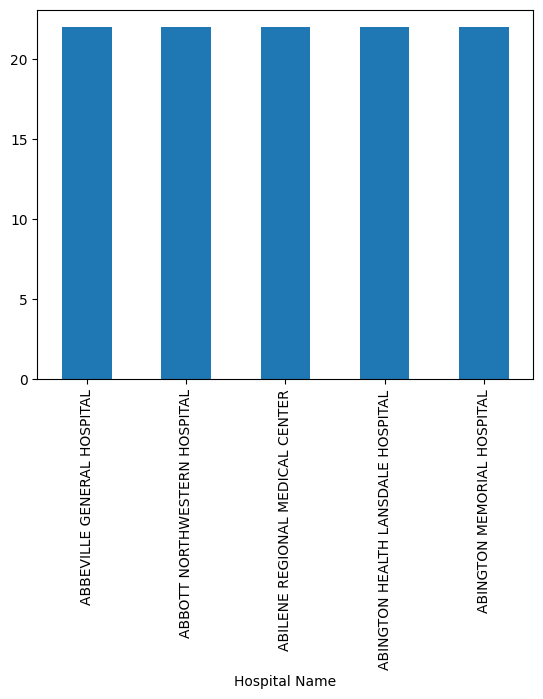

In [131]:
top_10_Hospital = medical.groupby('Hospital Name')['Avg Spending Per Episode (State)'].count().head()
top_10_Hospital.plot(kind='bar')

<Axes: xlabel='Percent of Spending (Hospital)'>

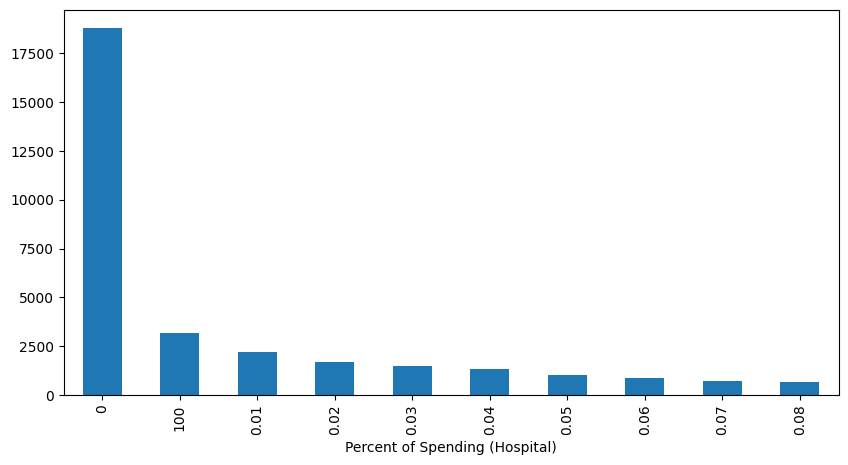

In [31]:
top_ten_Avg_Spending  = medical['Percent of Spending (Hospital)'].value_counts().head(10)
top_ten_Avg_Spending.plot(kind='bar', figsize=(10,5))


In [58]:
top_ten_states = medical.groupby('State')[['Percent of Spending (Nation)', 'Percent of Spending (Hospital)']].sum().sort_values(by='Percent of Spending (Nation)', ascending=False).head(10)

top_ten_states

,Percent of Spending (Nation),Percent of Spending (Hospital)
State,,
NJ,7.523.980.613.183.5616.190.55.421000.0700.030....,7.524.80.4513.892.7220.530.776.421000.0800.010...
AK,5.421000.0700.030.610.010.042.690045.49000.127...,6.341000.060.0100.4200.046.430052.63000.064.88...
AZ,5.421000.0700.030.610.010.042.690045.49000.127...,5.771000.0800.030.920.010.033.490048.3000.189....
WA,5.421000.0700.030.610.010.042.690045.49000.127...,4.991000.02000.650.020.022.670046.96000.096.38...
IA,45.49000.127.5203.5616.190.55.421000.0700.030....,48.78000.117.5703.9314.850.346.441000.02000.26...
NV,3.980.613.183.5616.190.55.421000.0700.030.610....,5.010.3813.93.2713.350.674.231000.100.060.550....
MI,16.190.55.421000.0700.030.610.010.042.690045.4...,22.970.524.411000.0700.010.4800.092.220046.370...
OR,16.190.55.421000.0700.030.610.010.042.690045.4...,25.40.363.761000001.070.050.031.90046.94000.19...
ME,13.1800.127.523.980.613.183.5616.190.55.421000...,9.2900.117.234.520.513.313.3711.670.414.411000...


In [62]:
inpatient_cost = medical[medical['Claim Type']=='Inpatient']

In [63]:
outpatient_cost = medical[medical['Claim Type']=='Outpatient']

In [70]:
inpatient_cost.drop(['Measure Start Date',  'Percent of Spending (Hospital)', 'Percent of Spending (State)','Percent of Spending (Nation)'], axis=1)



,index,Hospital Name,Provider Number,State,Period,Claim Type,Avg Spending Per Episode (Hospital),Avg Spending Per Episode (State),Avg Spending Per Episode (Nation),Measure End Date
5,5,HELEN KELLER HOSPITAL,10019,AL,1 through 30 days After Discharge from Index H...,Inpatient,2518,2634,2702,NaN
13,13,DALE MEDICAL CENTER,10021,AL,1 to 3 days Prior to Index Hospital Admission,Inpatient,12,6,5,NaN
20,20,DALE MEDICAL CENTER,10021,AL,During Index Hospital Admission,Inpatient,7529,8934,9324,NaN
27,27,DALE MEDICAL CENTER,10021,AL,1 through 30 days After Discharge from Index H...,Inpatient,2719,2634,2702,NaN
35,35,CHEROKEE MEDICAL CENTER,10022,AL,1 to 3 days Prior to Index Hospital Admission,Inpatient,0,6,5,NaN
...,...,...,...,...,...,...,...,...,...,...
69749,69749,OVERLAKE HOSPITAL MEDICAL CENTER,500051,WA,1 through 30 days After Discharge from Index H...,Inpatient,1469,1891,2702,NaN
69757,69757,TRIOS HEALTH,500053,WA,1 to 3 days Prior to Index Hospital Admission,Inpatient,4,4,5,NaN
69762,69762,OHIO VALLEY MEDICAL CENTER,510039,WV,During Index Hospital Admission,Inpatient,8301,8845,9324,NaN
69769,69769,OHIO VALLEY MEDICAL CENTER,510039,WV,1 through 30 days After Discharge from Index H...,Inpatient,3245,2862,2702,NaN


In [77]:
# Convert the spending columns to numeric, coercing errors
inpatient_cost['Avg Spending Per Episode (Hospital)'] = pd.to_numeric(inpatient_cost['Avg Spending Per Episode (Hospital)'], errors='coerce')
inpatient_cost['Avg Spending Per Episode (State)'] = pd.to_numeric(inpatient_cost['Avg Spending Per Episode (State)'], errors='coerce')
inpatient_cost['Avg Spending Per Episode (Nation)'] = pd.to_numeric(inpatient_cost['Avg Spending Per Episode (Nation)'], errors='coerce')


# Create a pivot table for inpatient cost by state
inpatient_state_pivot = pd.pivot_table(inpatient_cost,
                                        values=['Avg Spending Per Episode (Hospital)',
                                                'Avg Spending Per Episode (State)',
                                                'Avg Spending Per Episode (Nation)'],
                                        index=['State'],
                                        aggfunc='mean')

# Display the pivot table
display(inpatient_state_pivot)

,Avg Spending Per Episode (Hospital),Avg Spending Per Episode (Nation),Avg Spending Per Episode (State)
State,,,
AK,3669.875000,4010.333333,4060.333333
AL,3185.036585,4010.333333,3858.000000
AR,3738.325581,4010.333333,4191.333333
AZ,3957.204301,4010.333333,4277.000000
CA,3849.052874,4010.333333,4075.333333
CO,3967.985507,4010.333333,4175.666667
CT,3348.137931,4010.333333,3660.000000
DC,4239.142857,4010.333333,4206.333333
DE,3854.388889,4010.333333,4206.333333


In [78]:
inpatient_state = pd.pivot_table(inpatient_cost,index=['State'])

TypeError: agg function failed [how->mean,dtype->object]